In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter

# from RRAM.Representate import config_ax, setup_paper_plt, config_ax_state


In [62]:
def generar_espacio_filamentos_test(Ny: int, Nx: int, num_filamentos: int, grosor: int = 1, ruido: bool = False):
    """
    Genera una matriz 2D simulando múltiples filamentos RRAM.
    Los filamentos ocupan TODO el eje X (de columna 0 a Nx-1).
    """
    matriz = np.zeros((Ny, Nx), dtype=int)
    filamentos_ranges = []

    # --- 1. CÁLCULO MATEMÁTICO DE LOS RANGOS EN EL EJE Y ---
    paso = Ny // num_filamentos
    for i in range(num_filamentos):
        fila_min = i * paso
        fila_max = (i + 1) * paso - 1 if i < num_filamentos - 1 else Ny - 1
        filamentos_ranges.append((fila_min, fila_max))

    print(f"Rangos generados para {num_filamentos} filamentos en {Ny} filas: {filamentos_ranges}")

    # --- 2. GENERACIÓN DE LOS FILAMENTOS (Cruzando todo el eje X) ---
    for y_min, y_max in filamentos_ranges:
        # Iniciamos el filamento en el medio de su rango vertical permitido
        y_c = (y_min + y_max) // 2

        # Recorremos TODAS las columnas (Eje X completo)
        for x in range(Nx):
            if ruido:
                # El filamento "baila" aleatoriamente una fila arriba o abajo
                y_c += np.random.choice([-1, 0, 1])
                # Limitamos para que el centro no se salga de su rango asignado
                y_c = max(y_min + grosor, min(y_max - grosor, y_c))

            # Dibujamos el grosor en el eje Y (filas) para esta columna X
            y_inicio = max(y_min, y_c - grosor)
            y_fin = min(y_max, y_c + grosor)

            # Marcamos con 1 las celdas correspondientes
            matriz[y_inicio : y_fin + 1, x] = 1

    return matriz, filamentos_ranges


In [63]:
def obtener_centro_CF(types_map: np.ndarray, cf_ranges: list) -> list:
    """
    Calcula los centros de los filamentos identificando bloques contiguos en cada columna,
    y obteniendo la coordenada (fila) central que más se repite a lo largo de cada rango definido.

    Argumentos:
    - types_map: Matriz 2D del sistema donde 1 indica filamento y 0 vacío.
    - cf_ranges: (OBLIGATORIO) Lista de tuplas indicando el límite físico de cada filamento en el eje Y.
                 Ejemplo para 1 filamento: [(0, 99)].
                 Ejemplo para 2 filamentos: [(0, 49), (50, 99)].

    Retorna:
    - Una lista con los centros (números enteros de fila). Devuelve un centro exacto por cada rango.
    """
    Ny, Nx = types_map.shape
    todos_los_centros = []

    # Recorremos columnas (evitando electrodos 0 y Nx-1)
    for j in range(1, Nx - 1):
        column_data = types_map[:, j]

        # Encontramos los índices (filas) donde hay filamento en esta columna
        fil_indices = np.where(column_data == 1)[0]

        if len(fil_indices) == 0:
            continue

        # --- 1. ALGORITMO DE AGRUPACIÓN (CLUSTERING) ---
        clusters = []
        current_group = [fil_indices[0]]

        for i in range(1, len(fil_indices)):
            # Si el índice actual es consecutivo al anterior, pertenece al mismo bloque
            if fil_indices[i] == fil_indices[i - 1] + 1:
                current_group.append(fil_indices[i])
            else:
                # Se rompió la continuidad: guardamos el bloque y empezamos uno nuevo
                clusters.append(current_group)
                current_group = [fil_indices[i]]
        clusters.append(current_group)  # Guardar el último bloque

        # --- 2. CÁLCULO DEL CENTRO LOCAL DE CADA CLUSTER ---
        for cluster in clusters:
            # Calculamos la media aritmética de los índices (Ej: [18,19,20] -> 19.0)
            media = np.mean(cluster)

            # Redondeamos al entero más cercano y forzamos a que sea tipo 'int'
            centro_entero = int(np.round(media))

            # Guardamos el centro en la lista global del sistema
            todos_los_centros.append(centro_entero)

    # Si la matriz estaba vacía o no había filamentos en el interior
    if not todos_los_centros:
        return [None] * len(cf_ranges)

    # --- 3. OBTENER EL/LOS CENTROS MÁS REPETIDOS SEGÚN LOS RANGOS ---
    centros_por_filamento = []

    for fila_min, fila_max in cf_ranges:
        # Filtramos solo los centros que caen estrictamente dentro de este filamento físico
        centros_en_rango = [c for c in todos_los_centros if fila_min <= c <= fila_max]

        if centros_en_rango:
            # Obtenemos el que MAS se repite en esta región
            centro_ganador = Counter(centros_en_rango).most_common(1)[0][0]
            centros_por_filamento.append(centro_ganador)
        else:
            # Si un rango no tiene filamento formado, devolvemos None
            centros_por_filamento.append(None)

    return centros_por_filamento


In [64]:
def calcular_filas_intermedias(centros: list) -> tuple[list, list]:
    """
    Calcula la fila central (punto medio) entre los centros de filamentos consecutivos
    y las distancias físicas desde los centros hasta dicha fila media.

    Argumentos:
    - centros: Lista de enteros con los centros de cada filamento (Ej: [20, 50, 80]).
    - atom_size: Tamaño físico de cada celda del grid (Ej: 0.25).

    Retorna:
    - filas_medias: Lista de enteros con las filas intermedias (Ej: [35, 65]).
    - distancias: Lista de tuplas con las distancias desde cada filamento a la fila media (Ej: [(15, 15), (15, 15)]).
                  Formato: [(dist_centro1_a_medio, dist_centro2_a_medio), ...]
    """
    filas_medias = []
    distancias = []

    # Si hay menos de 2 filamentos, no hay distancia intermedia que calcular
    if not centros or len(centros) < 2:
        return filas_medias, distancias

    # Recorremos la lista emparejando el elemento actual con el siguiente
    for i in range(len(centros) - 1):
        centro_actual = centros[i]
        centro_siguiente = centros[i + 1]

        # En caso de que un filamento no se haya formado (None), no podemos calcular el medio
        if centro_actual is None or centro_siguiente is None:
            continue

        # Calculamos la media aritmética entre ambos centros
        medio = (centro_actual + centro_siguiente) / 2.0

        # Redondeamos al entero más cercano (fila de la matriz)
        fila_media = int(np.round(medio))
        filas_medias.append(fila_media)

        # Calculamos cuántas casillas hay de diferencia usando valor absoluto (abs)
        # y lo multiplicamos por el tamaño físico de la celda (atom_size)
        distancia_actual = abs(fila_media - centro_actual)
        distancia_siguiente = abs(centro_siguiente - fila_media)

        # Guardamos ambas distancias en la lista
        distancias.append((distancia_actual, distancia_siguiente))

    return filas_medias, distancias

In [65]:
def calcular_perfiles_muro(
    perfiles_filamentos: list, distancias_casillas: list, pendiente_temperatura: float, atom_size: float
) -> list:
    """
    Calcula el perfil de temperatura 1D para cada muro térmico basándose en
    la temperatura de su filamento correspondiente columna a columna.
    """

    # BLOQUE 1: Preparación del contenedor de resultados
    # -----------------------------------------------------------------
    # Crearemos una lista que almacenará tuplas. Cada tupla contendrá
    # (perfil_muro_arriba, perfil_muro_abajo) en formato de array 1D.
    perfiles_muros = []

    # Verificación de seguridad: debe haber un perfil de filamento más que distancias
    if len(perfiles_filamentos) < 2 or not distancias_casillas:
        return perfiles_muros

    # BLOQUE 2: Iteración sobre las interfaces (muros)
    # -----------------------------------------------------------------
    # Recorremos la lista de distancias. El índice 'i' representa el espacio
    # INTERMEDIO entre el filamento 'i' (arriba) y el filamento 'i+1' (abajo).
    for i in range(len(distancias_casillas)):
        casillas_arriba, casillas_abajo = distancias_casillas[i]

        # BLOQUE 3: Extracción de los perfiles de los filamentos origen
        # -----------------------------------------------------------------
        # El muro superior está influenciado por el filamento que tiene encima (i)
        T_filamento_arriba = perfiles_filamentos[i]

        # El muro inferior está influenciado por el filamento que tiene debajo (i+1)
        T_filamento_abajo = perfiles_filamentos[i + 1]

        # BLOQUE 4: Cálculo vectorizado de la temperatura
        # -----------------------------------------------------------------
        # Como T_filamento es un array de numpy (ej: 100 valores, uno por columna),
        # al sumar el término matemático se realiza la operación celda por celda
        # instantáneamente sin necesidad de hacer un bucle for anidado.

        # Ecuación: T_muro = T_filamento + factor * distancia
        # (Nota física: 'factor_temp' debería ser negativo si el calor cae al alejarse)
        T_muro_arriba = T_filamento_arriba + pendiente_temperatura * (casillas_arriba * atom_size)
        T_muro_abajo = T_filamento_abajo + pendiente_temperatura * (casillas_abajo * atom_size)

        # Guardamos el par de perfiles calculados para esta interfaz
        perfiles_muros.append((T_muro_arriba, T_muro_abajo))

    return perfiles_muros


In [66]:
def colocar_muro_termico(
    matriz_molde: np.ndarray, filas_intermedias: list, perfiles_muros_calculados: list
) -> np.ndarray:
    """
    Coloca los perfiles 1D de temperatura en las filas correspondientes de la matriz 2D.
    """
    matriz_muros = np.zeros_like(matriz_molde, dtype=float)
    Ny, Nx = matriz_muros.shape

    for i, fila_mid in enumerate(filas_intermedias):
        if fila_mid is None:
            continue

        # Extraemos los perfiles 1D ya calculados por tu nueva función
        perfil_muro_arriba, perfil_muro_abajo = perfiles_muros_calculados[i]

        # 1er Muro: Fila Intermedia
        mask_vacio_arriba = matriz_molde[fila_mid, :] == 0
        # Numpy asigna el valor del perfil SOLO en las columnas donde la máscara es True
        matriz_muros[fila_mid, mask_vacio_arriba] = perfil_muro_arriba[mask_vacio_arriba]

        # 2do Muro: Una fila por debajo
        fila_debajo = fila_mid - 1
        if 0 <= fila_debajo < Ny:
            mask_vacio_abajo = matriz_molde[fila_debajo, :] == 0
            matriz_muros[fila_debajo, mask_vacio_abajo] = perfil_muro_abajo[mask_vacio_abajo]

    return matriz_muros

In [67]:
def plot_centros_filamento(matriz_test, rangos_test, centros_calculados, filas_intermedias):
    """
    Genera un gráfico visualizando los centros de filamentos calculados.

    Parameters:
    -----------
    matriz_test : numpy.ndarray
        Matriz de datos a visualizar
    rangos_test : list of tuples
        Lista de tuplas (ymin, ymax) que definen los rangos de cada filamento
    centros_calculados : list
        Lista con las posiciones de los centros calculados
    filas_intermedias : list
        Lista con las posiciones de las filas intermedias
    """
    # Creamos el plot
    fig, ax = plt.subplots(figsize=(10, 12))

    # origin="lower" asegura que la fila 0 esté abajo y la 99 arriba
    cax = ax.imshow(matriz_test, cmap="Blues", origin="lower", aspect="equal")

    # Configuramos títulos y etiquetas
    ax.set_title(f"Test de Centros de Filamento ({len(rangos_test)} Filamentos)", pad=15, fontsize=14)
    ax.set_xlabel("Eje X - Columnas (Atraviesa de Electrodo a Electrodo)", fontsize=12)
    ax.set_ylabel("Eje Y - Filas (Grosor del Dieléctrico)", fontsize=12)

    # Dibujamos los límites de los rangos (Líneas grises punteadas)
    for idx, (ymin, ymax) in enumerate(rangos_test):
        if idx < len(rangos_test) - 1:
            ax.axhline(
                y=ymax + 0.5,
                color="gray",
                linestyle=":",
                alpha=0.8,
                linewidth=1.5,
                label="Límite de Rango" if idx == 0 else "",
            )

    # Dibujamos los CENTROS calculados (Líneas gruesas rojas)
    for idx, centro in enumerate(centros_calculados):
        if centro is not None:
            ax.axhline(
                y=centro,
                color="#D32F2F",
                linestyle="-",
                alpha=0.9,
                linewidth=2.5,
                label="Centro Calculado" if idx == 0 else "",
            )

    # Dibujamos las filas intermedias (Líneas verdes)
    for idx, fila_mid in enumerate(filas_intermedias):
        ax.axhline(
            y=fila_mid,
            color="#388E3C",
            linestyle="-.",
            alpha=0.9,
            linewidth=2,
            label="Fila Intermedia" if idx == 0 else "",
        )

    # Ajustes visuales (Grid y Leyenda)
    ax.grid(color="gray", linestyle="--", alpha=0.2)
    ax.legend(loc="upper right", framealpha=0.95)

    plt.tight_layout()
    plt.show()


In [68]:
def plot_muro_termico(matriz_muros: np.ndarray, matriz_molde: np.ndarray = None):
    """
    Dibuja la matriz resaltando la ubicación y temperatura de los muros térmicos.
    """
    fig, ax = plt.subplots(figsize=(10, 12))

    # 1. Si pasamos el molde, lo dibujamos en un gris muy suave de fondo
    if matriz_molde is not None:
        ax.imshow(matriz_molde, cmap="Greys", origin="lower", alpha=0.15)

    # 2. Enmascaramos los ceros para que la matriz de muros sea transparente donde no hay muro
    muros_visibles = np.ma.masked_where(matriz_muros == 0, matriz_muros)

    # 3. Ploteamos los muros usando un mapa de calor (ej. 'hot' o 'plasma')
    im = ax.imshow(muros_visibles, cmap="plasma", origin="lower")

    # Barra de color indicando la temperatura de los muros
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Fixed Boundary Temperature (K)", fontsize=12)

    # Estética
    ax.set_title("Thermal Walls Placement & Temperature", pad=15, fontsize=14)
    ax.set_xlabel("Eje X (Columnas)")
    ax.set_ylabel("Eje Y (Filas)")
    ax.grid(color="gray", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [69]:
def extraer_perfiles_filamentos(matriz_temperaturas: np.ndarray, filas_centros: list) -> list:
    """
    Extrae los perfiles de temperatura 1D (fila completa) de una matriz térmica 2D,
    basándose en una lista de filas específicas (centros de los filamentos).

    Argumentos:
    - matriz_temperaturas: Matriz 2D con los resultados del solver térmico.
    - filas_centros: Lista de enteros indicando las filas a extraer (Ej: [20, 80]).

    Retorna:
    - perfiles: Lista de arrays 1D correspondientes a la temperatura de cada filamento.
    """

    # BLOQUE 1: Preparación
    perfiles = []
    Ny, Nx = matriz_temperaturas.shape

    # BLOQUE 2: Iteración y Extracción
    for fila in filas_centros:
        # Caso A: El filamento no se formó (su centro es None)
        if fila is None:
            # Añadimos None a la lista para mantener la correspondencia de índices
            perfiles.append(None)
            print("Advertencia: Se detectó un filamento no formado (None). Perfil omitido.")

        # Caso B: La fila es un índice válido dentro de la matriz
        elif 0 <= fila < Ny:
            # Extraemos la fila completa (todas las columnas de esa fila)
            # Usamos .copy() para evitar modificar la matriz original accidentalmente
            perfil_1d = matriz_temperaturas[fila, :].copy()
            perfiles.append(perfil_1d)

        # Caso C: Índice fuera de los límites de la matriz (Error de entrada)
        else:
            raise IndexError(
                f"La fila solicitada ({fila}) está fuera de los límites de la matriz térmica (0 a {Ny - 1})."
            )

    return perfiles


Rangos generados para 2 filamentos en 40 filas: [(0, 19), (20, 39)]
Centros calculados para los rangos [(0, 19), (20, 39)]: [9, 29]
Filas intermedias: [19]
Distancias en casillas al centro: [(10, 10)]
Forma de la matriz de temperaturas: (40, 40)

--- Resultados de la Extracción ---
Filamento 1 (Fila 9): Extraído un perfil de 40 columnas.
   -> Primeros 5 valores térmicos: [766.2 742.8 321.4 703.4 725.4] K
Filamento 2 (Fila 29): Extraído un perfil de 40 columnas.
   -> Primeros 5 valores térmicos: [370.3 605.2 834.3 406.3 521.1] K
Perfiles de muros calculados para cada interfaz: [(array([768.71578099, 745.2807573 , 323.94262919, 705.92628631,
       727.85779765, 717.0919471 , 621.69179181, 595.86585915,
       510.28445598, 679.17171587, 435.59861267, 335.86209242,
       568.49740782, 571.78788826, 530.13260452, 317.55819507,
       900.59387273, 588.41608415, 813.54442541, 409.71178885,
       805.84266835, 374.03851966, 625.96269888, 358.29651352,
       567.87706429, 474.83430083, 

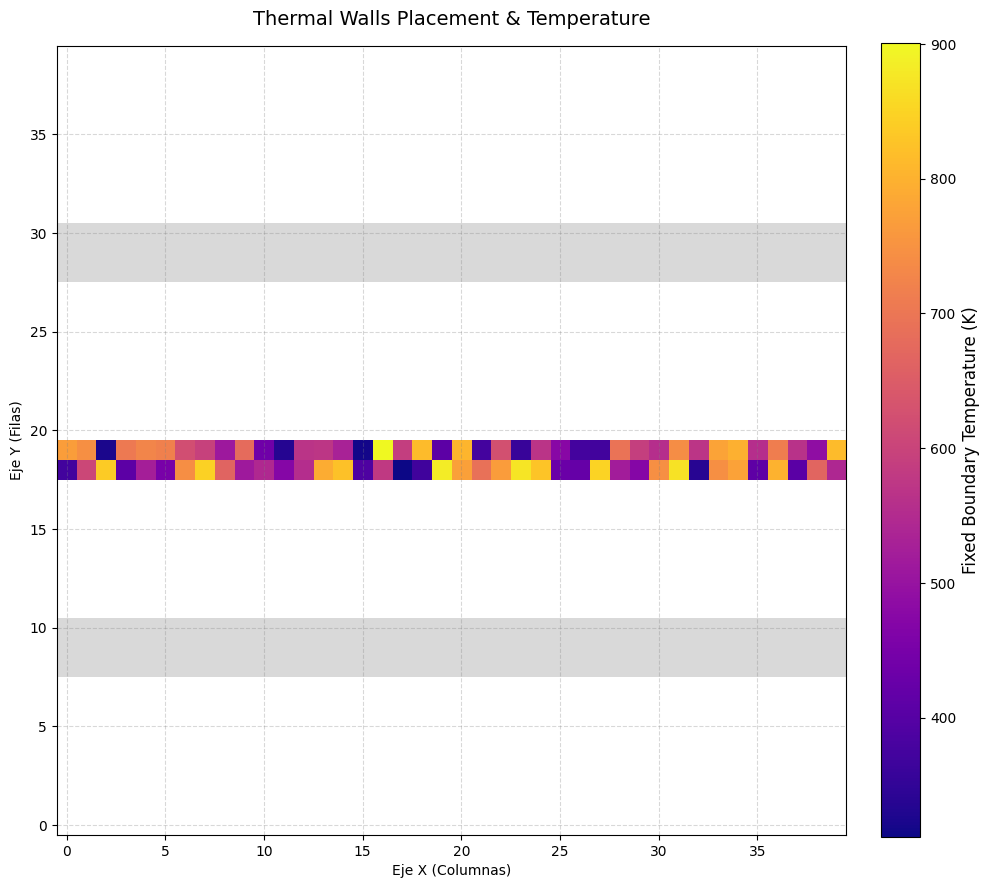

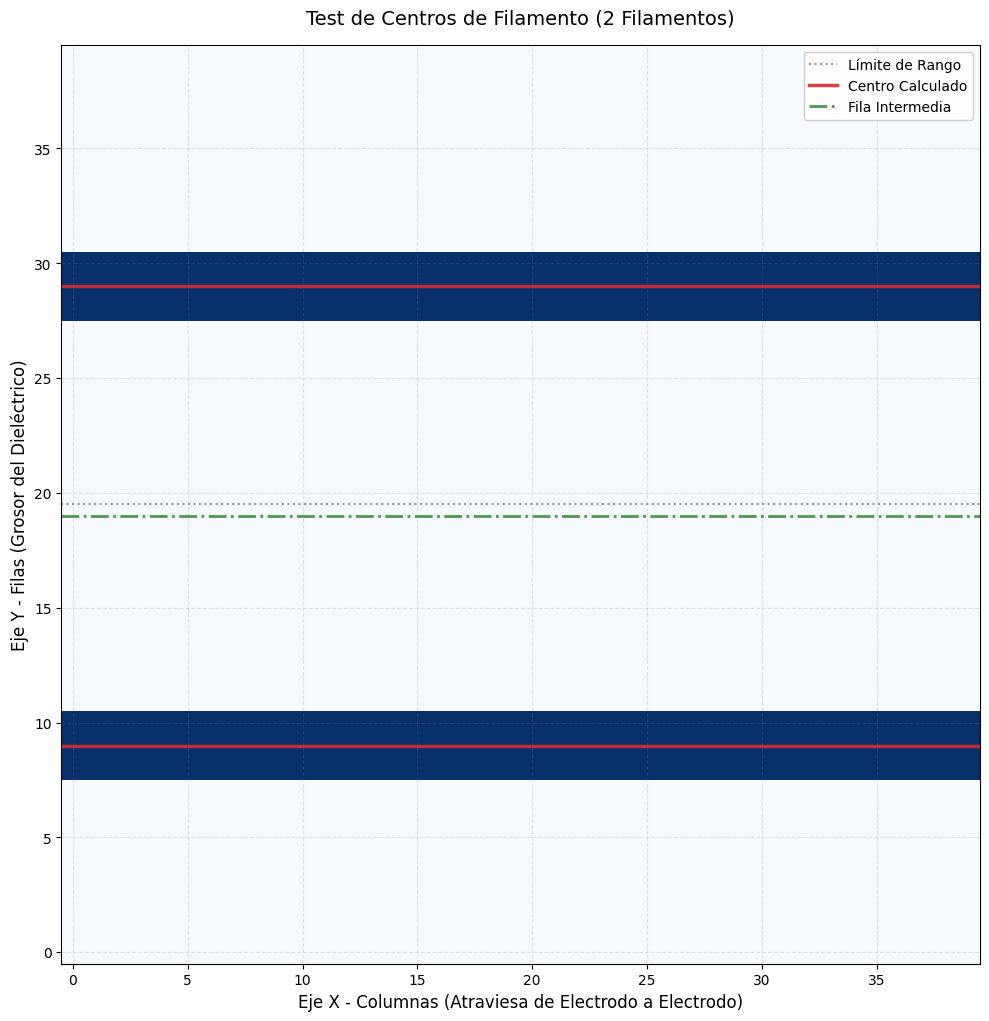

In [70]:
# Variables de prueba
atom_size = 0.25  # nm
pendiente_temperatura = 1  # K/nm (Por poner un ejemplo matemático)

Ny, Nx = 40, 40
matriz_test, rangos_test = generar_espacio_filamentos_test(Ny=Ny, Nx=Nx, num_filamentos=2, grosor=1, ruido=False)

# 2. Calculamos los centros con tu función matemática
centros_calculados = obtener_centro_CF(matriz_test, cf_ranges=rangos_test)
print(f"Centros calculados para los rangos {rangos_test}: {centros_calculados}")

filas_intermedias, dist_centro = calcular_filas_intermedias(centros_calculados)

filas_intermedias, dist_casillas = calcular_filas_intermedias(centros_calculados)

print(f"Filas intermedias: {filas_intermedias}")
print(f"Distancias en casillas al centro: {dist_casillas}")

mis_perfiles_filamentos = []

# 2. Generamos una matriz térmica aleatoria (valores entre 300K y 900K)
# np.random.uniform genera números decimales aleatorios en ese rango
matriz_temperaturas_mock = np.random.uniform(low=300.0, high=900.0, size=(Ny, Nx))

print(f"Forma de la matriz de temperaturas: {matriz_temperaturas_mock.shape}")

# 4. LLAMAMOS A LA FUNCIÓN DE EXTRACCIÓN
mis_perfiles_extraidos = extraer_perfiles_filamentos(
    matriz_temperaturas=matriz_temperaturas_mock, filas_centros=centros_calculados
)

# 5. Comprobamos los resultados
print("\n--- Resultados de la Extracción ---")
for i, (centro, perfil) in enumerate(zip(centros_calculados, mis_perfiles_extraidos)):
    if perfil is not None:
        print(f"Filamento {i + 1} (Fila {centro}): Extraído un perfil de {len(perfil)} columnas.")
        print(f"   -> Primeros 5 valores térmicos: {np.round(perfil[:5], 1)} K")
    else:
        print(f"Filamento {i + 1} (Fila {centro}): No se formó (None).")
   
# =====================================================================
# 5. CÁLCULO DE LOS PERFILES PARA LOS MUROS Y COLOCACIÓN
# =====================================================================
perfiles_muros_calculados = calcular_perfiles_muro(
    perfiles_filamentos=mis_perfiles_extraidos,
    distancias_casillas=dist_casillas,
    pendiente_temperatura=pendiente_temperatura,
    atom_size=atom_size,
)

print(f"Perfiles de muros calculados para cada interfaz: {perfiles_muros_calculados} pares de perfiles.")

matriz_temperaturas_fijas = colocar_muro_termico(
    matriz_molde=matriz_test, filas_intermedias=filas_intermedias, perfiles_muros_calculados=perfiles_muros_calculados
)

# =====================================================================
# 6. VISUALIZACIÓN DEL RESULTADO
# =====================================================================
plot_muro_termico(matriz_temperaturas_fijas, matriz_molde=matriz_test)
plot_centros_filamento(matriz_test, rangos_test, centros_calculados, filas_intermedias)
